In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/AI_Resume_Project/"

In [ ]:
with open(PROJECT_PATH + "backend/app.py", "w") as f:
    f.write("")

In [ ]:
with open(PROJECT_PATH + "frontend/ui_design.py", "w") as f:
    f.write("")

In [ ]:
with open(PROJECT_PATH + "requirements.txt", "w") as f:
    f.write("")

In [ ]:
with open(PROJECT_PATH + "README.md", "w") as f:
    f.write("")

In [ ]:
import os

for root, dirs, files in os.walk(PROJECT_PATH):
    print(root)
    for file in files:
        print("   ", file)

/content/drive/MyDrive/AI_Resume_Project/
    requirements.txt
    README.md
/content/drive/MyDrive/AI_Resume_Project/backend
    app.py
    label_encoder.pkl
    tfidf.pkl
/content/drive/MyDrive/AI_Resume_Project/backend/models
/content/drive/MyDrive/AI_Resume_Project/frontend
    ui_design.py
/content/drive/MyDrive/AI_Resume_Project/frontend/assets
/content/drive/MyDrive/AI_Resume_Project/frontend/pages
/content/drive/MyDrive/AI_Resume_Project/dataset
    job_descriptions.csv
    Resume.csv
/content/drive/MyDrive/AI_Resume_Project/notebook
    Copy of AI_Resume_Project.ipynb


In [ ]:
!pip install nltk tensorflow scikit-learn matplotlib seaborn plotly pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 81.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import pickle

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
print(os.listdir('/content/drive/MyDrive/AI_Resume_Project'))

['backend', 'frontend', 'dataset', 'notebook', 'requirements.txt', 'README.md']


In [ ]:
print(os.listdir('/content/drive/MyDrive/AI_Resume_Project/dataset'))


['job_descriptions.csv', 'Resume.csv']


In [ ]:
resume_df = pd.read_csv(
    PROJECT_PATH + "dataset/Resume.csv"
)

resume_df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
job_df = pd.read_csv(
    PROJECT_PATH + "dataset/job_descriptions.csv"
)

job_df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [ ]:
resume_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [ ]:
resume_df.describe(include='all')

,ID,Resume_str,Resume_html,Category
count,2.484000e+03,2484,2484,2484
unique,NaN,2482,2482,24
top,NaN,STOREKEEPER II Professional Sum...,"<div class=""fontsize fontface vmargins hmargin...",INFORMATION-TECHNOLOGY
freq,NaN,2,2,120
mean,3.182616e+07,NaN,NaN,NaN
std,2.145735e+07,NaN,NaN,NaN
min,3.547447e+06,NaN,NaN,NaN
25%,1.754430e+07,NaN,NaN,NaN
50%,2.521031e+07,NaN,NaN,NaN
75%,3.611444e+07,NaN,NaN,NaN


In [ ]:
job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615940 entries, 0 to 1615939
Data columns (total 23 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Job Id            1615940 non-null  int64  
 1   Experience        1615940 non-null  object 
 2   Qualifications    1615940 non-null  object 
 3   Salary Range      1615940 non-null  object 
 4   location          1615940 non-null  object 
 5   Country           1615940 non-null  object 
 6   latitude          1615940 non-null  float64
 7   longitude         1615940 non-null  float64
 8   Work Type         1615940 non-null  object 
 9   Company Size      1615940 non-null  int64  
 10  Job Posting Date  1615940 non-null  object 
 11  Preference        1615940 non-null  object 
 12  Contact Person    1615940 non-null  object 
 13  Contact           1615940 non-null  object 
 14  Job Title         1615940 non-null  object 
 15  Role              1615940 non-null  object 
 16  

In [ ]:
job_df.describe(include='all')

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
count,1.615940e+06,1615940,1615940,1615940,1615940,1615940,1.615940e+06,1.615940e+06,1615940,1.615940e+06,...,1615940,1615940,1615940,1615940,1615940,1615940,1615940,1615940,1615940,1610462
unique,NaN,48,10,561,214,216,NaN,NaN,5,NaN,...,1615933,147,376,16,376,11,376,375,888,884
top,NaN,5 to 8 Years,BBA,$59K-$88K,Seoul,Malta,NaN,NaN,Part-Time,NaN,...,518.951.8103,UX/UI Designer,Interaction Designer,FlexJobs,Interaction Designers specialize in designing ...,"{'Childcare Assistance, Paid Time Off (PTO), R...",Interaction design principles User behavior an...,"Work on interaction design, defining how users...",DTE Energy,"{""Sector"":""Automotive"",""Industry"":""Automotive""..."
freq,NaN,34120,162148,3043,15104,7723,NaN,NaN,324044,NaN,...,2,48551,20580,129879,20580,161924,20580,20580,1957,3572
mean,1.548935e+15,NaN,NaN,NaN,NaN,NaN,1.937743e+01,1.639926e+01,NaN,7.370467e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,8.946722e+14,NaN,NaN,NaN,NaN,NaN,2.355690e+01,7.066762e+01,NaN,3.529886e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.817948e+11,NaN,NaN,NaN,NaN,NaN,-4.090060e+01,-1.751982e+02,NaN,1.264600e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,7.740508e+14,NaN,NaN,NaN,NaN,NaN,5.152100e+00,-1.531010e+01,NaN,4.311400e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.547858e+15,NaN,NaN,NaN,NaN,NaN,1.807080e+01,1.914510e+01,NaN,7.363300e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.323729e+15,NaN,NaN,NaN,NaN,NaN,3.907420e+01,4.757690e+01,NaN,1.043000e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
resume_df['resume_length'] = resume_df['Resume_str'].astype(str).apply(len)

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

resume_df['Category_Encoded'] = encoder.fit_transform(
    resume_df['Category']
)

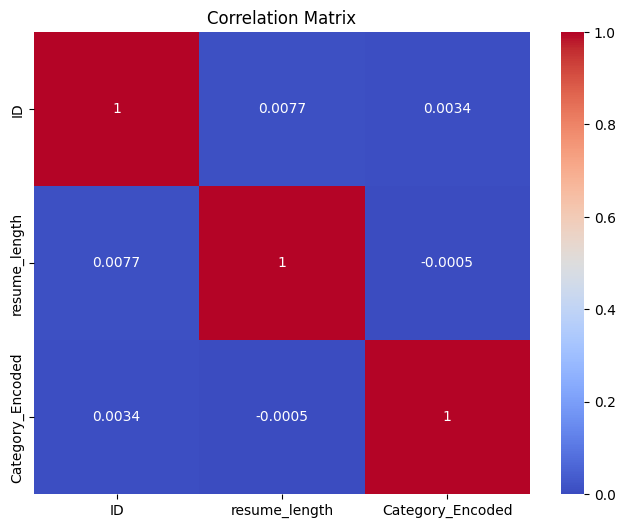

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = resume_df[
    ['ID', 'resume_length', 'Category_Encoded']
]

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text)

    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    text = text.lower()

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [ ]:
resume_df['cleaned_resume'] = resume_df[
    'Resume_str'
].apply(clean_text)

In [ ]:
resume_df[
    ['Resume_str','cleaned_resume']
].head()

,Resume_str,cleaned_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary years experience recruitin...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


In [ ]:
import pickle

pickle.dump(
    encoder,
    open(
        PROJECT_PATH +
        "backend/label_encoder.pkl",
        "wb"
    )
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    resume_df['cleaned_resume']
).toarray()

y = resume_df['Category_Encoded']

In [ ]:
pickle.dump(
    tfidf,
    open(
        PROJECT_PATH +
        "backend/tfidf.pkl",
        "wb"
    )
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
resume_df['Category_Encoded'] = encoder.fit_transform(
    resume_df['Category']
)

print("Number of Categories:")
print(resume_df['Category'].nunique())

print("\nSample Categories:")
print(resume_df[['Category','Category_Encoded']].head())

Number of Categories:
24

Sample Categories:
  Category  Category_Encoded
0       HR                19
1       HR                19
2       HR                19
3       HR                19
4       HR                19


In [ ]:
X = tfidf.fit_transform(
    resume_df['cleaned_resume']
).toarray()

y = resume_df['Category_Encoded']

In [ ]:
print(X.shape)
print(y.shape)

(2484, 5000)
(2484,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1987, 5000)
(497, 5000)
(1987,)
(497,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6780684104627767


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(
    y_test,
    gb_pred
)

print("Gradient Boosting Accuracy:",
      gb_accuracy)

Gradient Boosting Accuracy: 0.710261569416499


In [ ]:
!find /content/drive/MyDrive -name "*.pkl"

/content/drive/MyDrive/AI_Resume_Project/backend/label_encoder.pkl
/content/drive/MyDrive/AI_Resume_Project/backend/tfidf.pkl


In [ ]:
print("Random Forest Accuracy:",
      round(rf_accuracy*100,2), "%")

print("Gradient Boosting Accuracy:",
      round(gb_accuracy*100,2), "%")

Random Forest Accuracy: 67.81 %
Gradient Boosting Accuracy: 71.03 %


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.79      0.90      0.84        29
           1       0.70      0.70      0.70        30
           2       0.50      0.38      0.43         8
           3       0.71      0.50      0.59        20
           4       0.33      0.17      0.22        18
           5       0.00      0.00      0.00         6
           6       0.86      0.90      0.88        21
           7       0.80      0.70      0.74        23
           8       0.00      0.00      0.00         2
           9       0.75      0.56      0.64        27
          10       0.90      0.75      0.82        24
          11       0.88      0.88      0.88        34
          12       0.64      0.35      0.45        20
          13       0.79      1.00      0.88        19
          14       0.78      0.56      0.65        25
          15       0.58      0.67      0.62        21
          16       0.50      0.58      0.54        19
          17       0.59    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(
    classification_report(
        y_test,
        gb_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.90      0.88        29
           1       0.88      0.77      0.82        30
           2       0.57      0.50      0.53         8
           3       0.48      0.60      0.53        20
           4       0.53      0.56      0.54        18
           5       0.14      0.17      0.15         6
           6       0.86      0.86      0.86        21
           7       0.62      0.65      0.64        23
           8       0.20      0.50      0.29         2
           9       0.65      0.41      0.50        27
          10       0.95      0.79      0.86        24
          11       0.88      0.88      0.88        34
          12       0.75      0.60      0.67        20
          13       0.83      1.00      0.90        19
          14       0.77      0.68      0.72        25
          15       0.73      0.76      0.74        21
          16       0.63      0.63      0.63        19
          17       0.82    

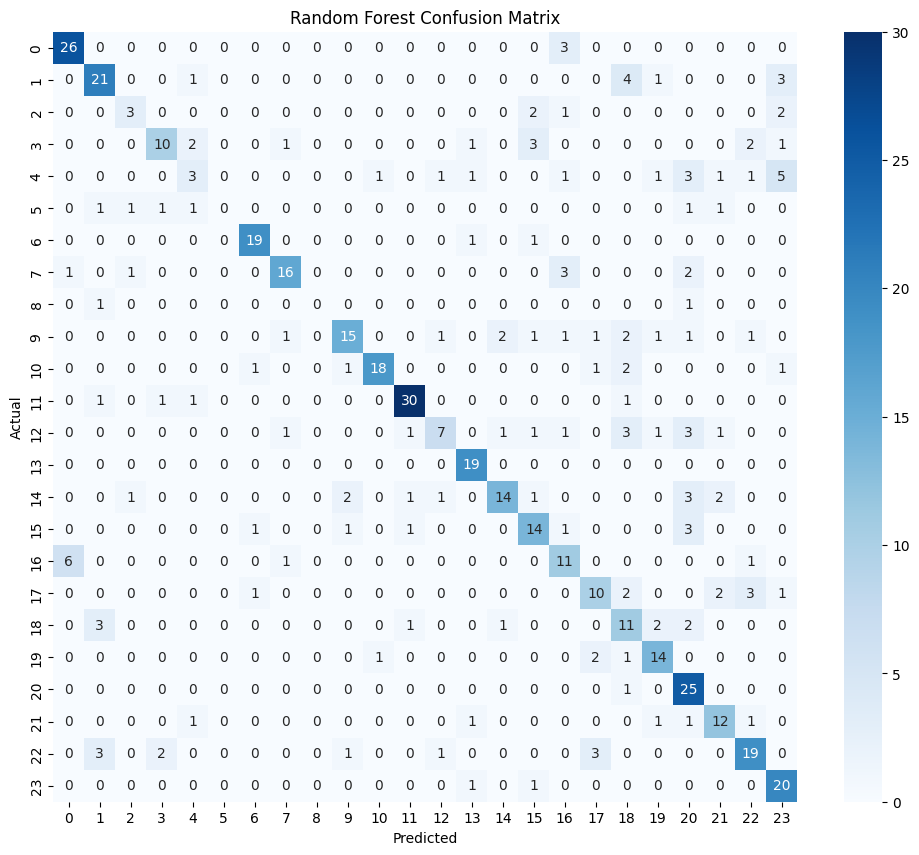

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

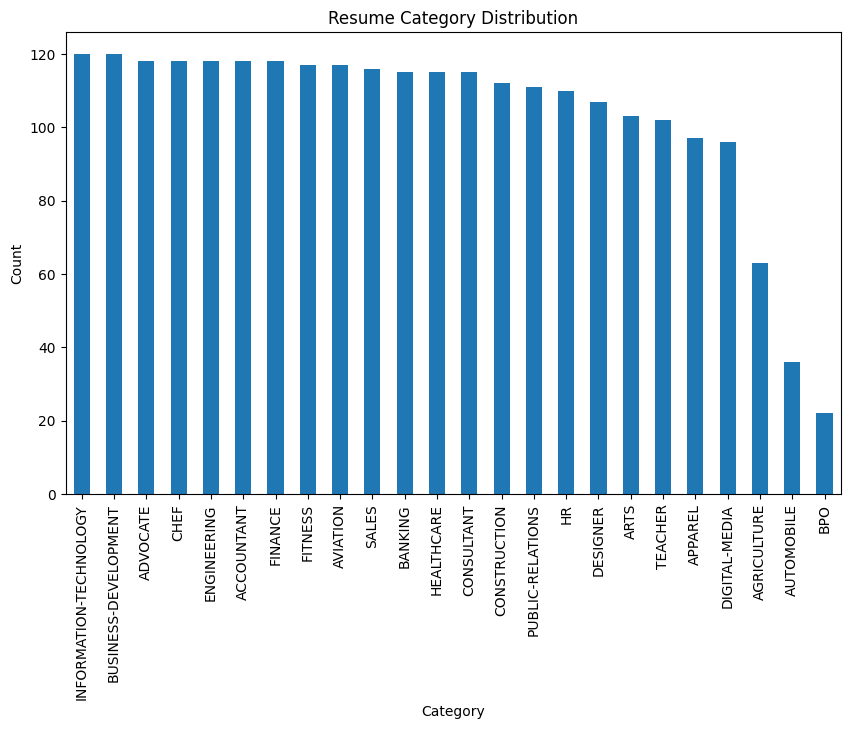

In [ ]:
plt.figure(figsize=(10,6))

resume_df['Category'].value_counts().plot(
    kind='bar'
)

plt.title("Resume Category Distribution")

plt.xlabel("Category")

plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatterpolar(
        r=[rf_accuracy],
        theta=['Accuracy'],
        fill='toself',
        name='Random Forest'
    )
)

fig.add_trace(
    go.Scatterpolar(
        r=[gb_accuracy],
        theta=['Accuracy'],
        fill='toself',
        name='Gradient Boosting'
    )
)

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0,1]
        )
    ),
    showlegend=True
)

fig.show()

In [ ]:
import pickle

pickle.dump(
    rf_model,
    open(
        PROJECT_PATH +
        "backend/models/rf_model.pkl",
        "wb"
    )
)

pickle.dump(
    gb_model,
    open(
        PROJECT_PATH +
        "backend/models/gb_model.pkl",
        "wb"
    )
)

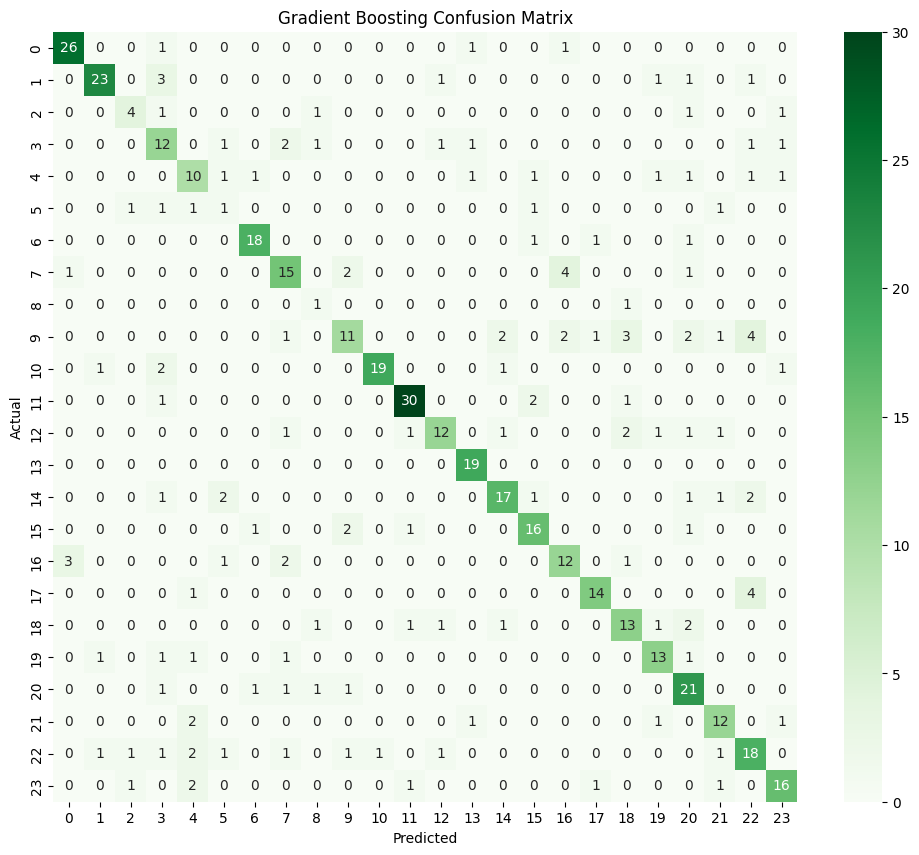

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_gb = confusion_matrix(
    y_test,
    gb_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "Gradient Boosting Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

rf_tuned_pred = rf_tuned.predict(X_test)

rf_tuned_acc = accuracy_score(
    y_test,
    rf_tuned_pred
)

print("Tuned RF Accuracy:", rf_tuned_acc)

Tuned RF Accuracy: 0.6841046277665996


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb_tuned = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_tuned.fit(X_train, y_train)

gb_tuned_pred = gb_tuned.predict(X_test)

gb_tuned_acc = accuracy_score(
    y_test,
    gb_tuned_pred
)

print("Tuned GB Accuracy:", gb_tuned_acc)

Tuned GB Accuracy: 0.7263581488933601


In [ ]:
import pickle

pickle.dump(
    gb_tuned,
    open(
        PROJECT_PATH + "backend/models/gb_model.pkl",
        "wb"
    )
)

pickle.dump(
    rf_tuned,
    open(
        PROJECT_PATH + "backend/models/rf_model.pkl",
        "wb"
    )
)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
tokenizer = Tokenizer(
    num_words=5000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    resume_df['cleaned_resume']
)

In [ ]:
X_dl = tokenizer.texts_to_sequences(
    resume_df['cleaned_resume']
)

In [ ]:
X_dl = pad_sequences(
    X_dl,
    maxlen=200,
    padding='post',
    truncating='post'
)

In [ ]:
print(X_dl.shape)

(2484, 200)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print(X_train_dl.shape)
print(X_test_dl.shape)

(1987, 200)
(497, 200)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

In [ ]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=200
    )
)

lstm_model.add(
    LSTM(128)
)

lstm_model.add(
    Dropout(0.3)
)

lstm_model.add(
    Dense(64, activation='relu')
)

lstm_model.add(
    Dense(
        len(resume_df['Category_Encoded'].unique()),
        activation='softmax'
    )
)

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = lstm_model.fit(
    X_train_dl,
    y_train_dl,
    validation_data=(
        X_test_dl,
        y_test_dl
    ),
    epochs=5,
    batch_size=32
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 404ms/step - accuracy: 0.0569 - loss: 3.1642 - val_accuracy: 0.0423 - val_loss: 3.1420
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 422ms/step - accuracy: 0.1127 - loss: 3.0157 - val_accuracy: 0.1187 - val_loss: 2.9041
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 429ms/step - accuracy: 0.1777 - loss: 2.7304 - val_accuracy: 0.1771 - val_loss: 2.8371
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 445ms/step - accuracy: 0.2687 - loss: 2.3782 - val_accuracy: 0.1670 - val_loss: 2.7244
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 398ms/step - accuracy: 0.4394 - loss: 1.8470 - val_accuracy: 0.2334 - val_loss: 2.8393


In [ ]:
lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test_dl,
    y_test_dl
)

print(
    "LSTM Accuracy:",
    round(lstm_acc*100,2),
    "%"
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.2334 - loss: 2.8393
LSTM Accuracy: 23.34 %


In [ ]:
from tensorflow.keras.layers import (
    Conv1D,
    GlobalMaxPooling1D
)

In [ ]:
cnn_model = Sequential()

cnn_model.add(
    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=200
    )
)

cnn_model.add(
    Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu'
    )
)

cnn_model.add(
    GlobalMaxPooling1D()
)

cnn_model.add(
    Dense(64, activation='relu')
)

cnn_model.add(
    Dropout(0.3)
)

cnn_model.add(
    Dense(
        len(resume_df['Category_Encoded'].unique()),
        activation='softmax'
    )
)

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = cnn_model.fit(
    X_train_dl,
    y_train_dl,
    validation_data=(
        X_test_dl,
        y_test_dl
    ),
    epochs=5,
    batch_size=32
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 142ms/step - accuracy: 0.0599 - loss: 3.1497 - val_accuracy: 0.0724 - val_loss: 3.0831
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.2808 - loss: 2.8343 - val_accuracy: 0.4447 - val_loss: 2.4097
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.4947 - loss: 2.0251 - val_accuracy: 0.6298 - val_loss: 1.6115
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.6472 - loss: 1.4034 - val_accuracy: 0.6962 - val_loss: 1.2151
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 128ms/step - accuracy: 0.7514 - loss: 0.9747 - val_accuracy: 0.7485 - val_loss: 1.0041


In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    X_test_dl,
    y_test_dl
)

print(
    "CNN Accuracy:",
    round(cnn_acc*100,2),
    "%"
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7485 - loss: 1.0041
CNN Accuracy: 74.85 %


In [ ]:
lstm_model.save(
    PROJECT_PATH +
    "backend/models/lstm_model.h5"
)

cnn_model.save(
    PROJECT_PATH +
    "backend/models/cnn_model.h5"
)

In [ ]:
import pickle

pickle.dump(
    tokenizer,
    open(
        PROJECT_PATH +
        "backend/tokenizer.pkl",
        "wb"
    )
)

In [ ]:
history_cnn = cnn_model.fit(
    X_train_dl,
    y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=10,
    batch_size=32
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.8153 - loss: 0.7170 - val_accuracy: 0.7586 - val_loss: 0.9147
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.8923 - loss: 0.5046 - val_accuracy: 0.7706 - val_loss: 0.8892
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.9305 - loss: 0.3482 - val_accuracy: 0.7746 - val_loss: 0.8467
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.9582 - loss: 0.2288 - val_accuracy: 0.7948 - val_loss: 0.8560
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.9768 - loss: 0.1604 - val_accuracy: 0.8028 - val_loss: 0.8494
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.9879 - loss: 0.1114 - val_accuracy: 0.7968 - val_loss: 0.8407
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.9879 - loss: 0.0829 - val_accuracy: 0.7907 - val_loss: 0.8635
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.9909 - loss: 0.0684 - val_accuracy: 0.

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    X_test_dl,
    y_test_dl
)

print(
    "CNN Accuracy:",
    round(cnn_acc*100,2),
    "%"
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7988 - loss: 0.8975
CNN Accuracy: 79.88 %


In [ ]:
history_lstm = lstm_model.fit(
    X_train_dl,
    y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=10,
    batch_size=32
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 560ms/step - accuracy: 0.6085 - loss: 1.3342 - val_accuracy: 0.2193 - val_loss: 2.9812
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 521ms/step - accuracy: 0.7227 - loss: 0.9217 - val_accuracy: 0.2193 - val_loss: 3.3975
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 446ms/step - accuracy: 0.8203 - loss: 0.6319 - val_accuracy: 0.2274 - val_loss: 3.8991
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 399ms/step - accuracy: 0.9004 - loss: 0.3740 - val_accuracy: 0.2012 - val_loss: 4.3545
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 440ms/step - accuracy: 0.9311 - loss: 0.2748 - val_accuracy: 0.2032 - val_loss: 4.4248
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 447ms/step - accuracy: 0.9351 - loss: 0.2404 - val_accuracy: 0.1831 - val_loss: 4.8678
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 446ms/step - accuracy: 0.9411 - loss: 0.2277 - val_accuracy: 0.2113 - val_loss: 4.9409
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 447ms/step - accuracy: 0.9547 - loss: 0.1761 - val_accu

In [ ]:
lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test_dl,
    y_test_dl
)

print(
    "LSTM Accuracy:",
    round(lstm_acc*100,2),
    "%"
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 186ms/step - accuracy: 0.1952 - loss: 5.5138
LSTM Accuracy: 19.52 %


In [ ]:
lstm_model.save(
    PROJECT_PATH +
    "backend/models/lstm_model.h5"
)

cnn_model.save(
    PROJECT_PATH +
    "backend/models/cnn_model.h5"
)

In [ ]:
import pickle

pickle.dump(
    tokenizer,
    open(
        PROJECT_PATH +
        "backend/tokenizer.pkl",
        "wb"
    )
)

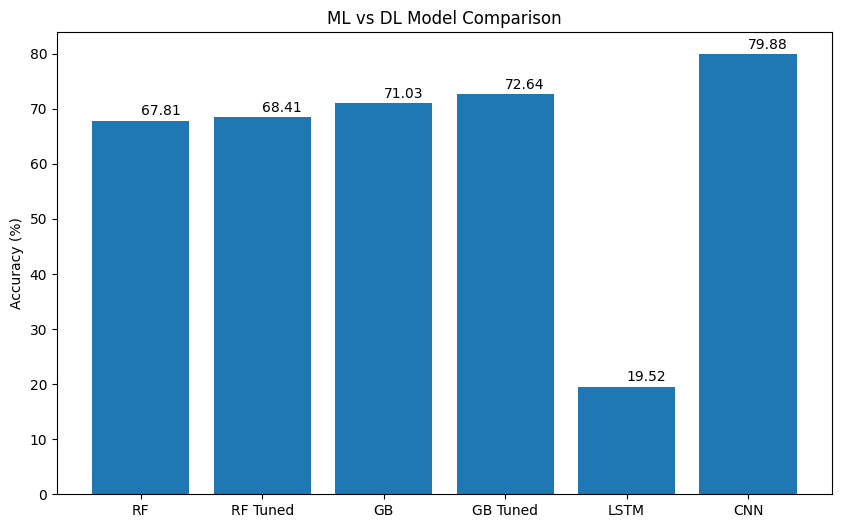

In [ ]:
import matplotlib.pyplot as plt

models = [
    'RF',
    'RF Tuned',
    'GB',
    'GB Tuned',
    'LSTM',
    'CNN'
]

accuracies = [
    67.81,
    68.41,
    71.03,
    72.64,
    19.52,
    79.88
]

plt.figure(figsize=(10,6))

plt.bar(models, accuracies)

plt.ylabel('Accuracy (%)')

plt.title('ML vs DL Model Comparison')

for i, v in enumerate(accuracies):
    plt.text(i, v+1, str(v))

plt.show()

In [ ]:
import os

print(os.listdir(PROJECT_PATH + "backend/models"))

['rf_model.pkl', 'gb_model.pkl', 'lstm_model.h5', 'cnn_model.h5']


In [ ]:
import os

models_path = PROJECT_PATH + "backend/models"

for file in os.listdir(models_path):
    full_path = os.path.join(models_path, file)

    print(
        file,
        " | Size:",
        round(os.path.getsize(full_path)/1024,2),
        "KB"
    )

rf_model.pkl  | Size: 89303.35 KB
gb_model.pkl  | Size: 4403.76 KB
lstm_model.h5  | Size: 9196.88 KB
cnn_model.h5  | Size: 8614.95 KB


In [ ]:
import pickle

rf = pickle.load(
    open(
        PROJECT_PATH +
        "backend/models/rf_model.pkl",
        "rb"
    )
)

print("RF Model Loaded Successfully")

RF Model Loaded Successfully


In [ ]:
gb = pickle.load(
    open(
        PROJECT_PATH +
        "backend/models/gb_model.pkl",
        "rb"
    )
)

print("GB Model Loaded Successfully")

GB Model Loaded Successfully


In [ ]:
from tensorflow.keras.models import load_model

cnn = load_model(
    PROJECT_PATH +
    "backend/models/cnn_model.h5"
)

print("CNN Loaded Successfully")

CNN Loaded Successfully


In [ ]:
lstm = load_model(
    PROJECT_PATH +
    "backend/models/lstm_model.h5"
)

print("LSTM Loaded Successfully")

LSTM Loaded Successfully


In [ ]:
import plotly.graph_objects as go

models = [
    'RF',
    'RF Tuned',
    'GB',
    'GB Tuned',
    'LSTM',
    'CNN'
]

scores = [
    67.81,
    68.41,
    71.03,
    72.64,
    19.52,
    79.88
]

fig = go.Figure()

fig.add_trace(
    go.Scatterpolar(
        r=scores,
        theta=models,
        fill='toself',
        name='Model Comparison'
    )
)

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0,100]
        )
    ),
    showlegend=True
)

fig.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


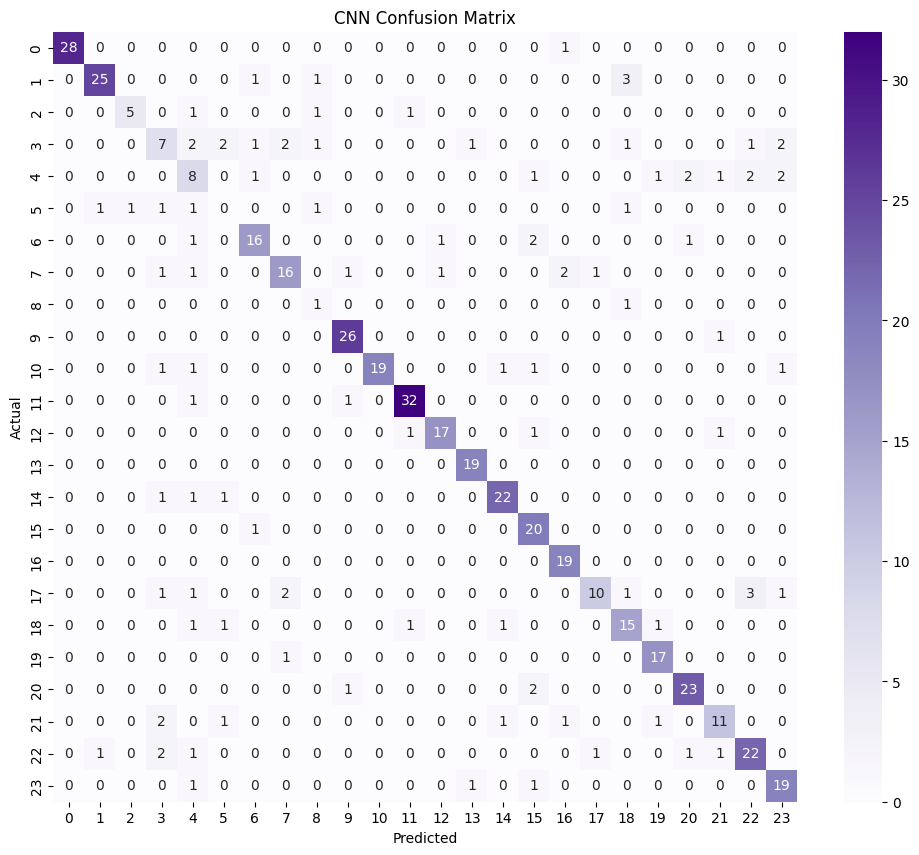

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cnn_pred = np.argmax(
    cnn_model.predict(X_test_dl),
    axis=1
)

cm_cnn = confusion_matrix(
    y_test_dl,
    cnn_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("CNN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
job_df['combined_text'] = (
    job_df['Job Title'].astype(str) + " " +
    job_df['Role'].astype(str) + " " +
    job_df['skills'].astype(str) + " " +
    job_df['Job Description'].astype(str)
)

In [ ]:
job_df['combined_text'] = job_df[
    'combined_text'
].apply(clean_text)

In [ ]:
job_df[
    ['Job Title','combined_text']
].head()

,Job Title,combined_text
0,Digital Marketing Specialist,digital marketing specialist social media mana...
1,Web Developer,web developer frontend web developer html css ...
2,Operations Manager,operations manager quality control manager qua...
3,Network Engineer,network engineer wireless network engineer wir...
4,Event Manager,event manager conference manager event plannin...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

job_tfidf = TfidfVectorizer(
    max_features=5000
)

job_vectors = job_tfidf.fit_transform(
    job_df['combined_text']
)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
resume_text = resume_df[
    'cleaned_resume'
].iloc[0]

In [ ]:
resume_vector = job_tfidf.transform(
    [resume_text]
)

In [ ]:
similarity_scores = cosine_similarity(
    resume_vector,
    job_vectors
)

In [ ]:
top_indices = similarity_scores[0].argsort()[-5:][::-1]

In [ ]:
job_df.iloc[
    top_indices
][[
    'Job Title',
    'Role',
    'Company'
]]

,Job Title,Role,Company
1157787,Customer Service Manager,Customer Support Manager,Peter Kiewit Sons
1157513,Customer Service Manager,Customer Support Manager,Clorox Company
1344679,Customer Service Manager,Customer Support Manager,Mahindra & Mahindra
1344458,Customer Service Manager,Customer Support Manager,Xiaomi Corporation
1345062,Customer Service Manager,Customer Support Manager,Best Buy


In [ ]:
def ats_score(
        resume_text,
        job_description
    ):

    vectors = job_tfidf.transform(
        [resume_text,
         job_description]
    )

    score = cosine_similarity(
        vectors[0],
        vectors[1]
    )[0][0]

    return round(
        score * 100,
        2
    )

In [ ]:
score = ats_score(
    resume_df[
        'cleaned_resume'
    ].iloc[0],

    job_df[
        'combined_text'
    ].iloc[0]
)

print(
    "ATS Score:",
    score,
    "%"
)

ATS Score: 6.29 %


In [ ]:
def skill_gap_analysis(
        resume_text,
        job_skills
    ):

    resume_words = set(
        resume_text.lower().split()
    )

    job_words = set(
        str(job_skills).lower().split()
    )

    missing_skills = (
        job_words -
        resume_words
    )

    return list(
        missing_skills
    )[:20]

In [ ]:
def skill_gap_analysis(
        resume_text,
        job_skills
    ):

    resume_words = set(
        clean_text(resume_text).split()
    )

    job_words = set(
        clean_text(job_skills).split()
    )

    missing = job_words - resume_words

    return sorted(list(missing))[:15]

In [ ]:
def career_guidance(
        ats_score
    ):

    if ats_score >= 80:
        return "Excellent Match"

    elif ats_score >= 60:
        return "Good Match"

    elif ats_score >= 40:
        return "Needs Skill Improvement"

    else:
        return "Strong Upskilling Recommended"

In [ ]:
career_guidance(score)

'Strong Upskilling Recommended'

In [ ]:
best_job_index = top_indices[0]

best_job_description = job_df.loc[
    best_job_index,
    'combined_text'
]

score = ats_score(
    resume_df['cleaned_resume'].iloc[0],
    best_job_description
)

print(score)

30.38


In [ ]:
import pickle

pickle.dump(
    job_tfidf,
    open(
        PROJECT_PATH +
        "backend/job_tfidf.pkl",
        "wb"
    )
)

job_df.to_csv(
    PROJECT_PATH +
    "backend/jobs_processed.csv",
    index=False
)

In [ ]:
print(os.listdir(PROJECT_PATH + "backend"))

['models', 'app.py', 'label_encoder.pkl', 'tfidf.pkl', 'tokenizer.pkl', 'job_tfidf.pkl', 'jobs_processed.csv']


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
PROJECT_PATH = "/content/drive/MyDrive/AI_Resume_Project/"

In [3]:
import os

print(os.listdir(PROJECT_PATH + "backend"))

['models', 'app.py', 'label_encoder.pkl', 'tfidf.pkl', 'tokenizer.pkl', 'jobs_processed.csv', 'job_tfidf.pkl']


In [5]:
import pickle

encoder = pickle.load(
    open(
        PROJECT_PATH + "backend/label_encoder.pkl",
        "rb"
    )
)

print("Encoder Loaded Successfully")

Encoder Loaded Successfully


In [6]:
category_mapping = dict(
    zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
)

print(category_mapping)

{'ACCOUNTANT': np.int64(0), 'ADVOCATE': np.int64(1), 'AGRICULTURE': np.int64(2), 'APPAREL': np.int64(3), 'ARTS': np.int64(4), 'AUTOMOBILE': np.int64(5), 'AVIATION': np.int64(6), 'BANKING': np.int64(7), 'BPO': np.int64(8), 'BUSINESS-DEVELOPMENT': np.int64(9), 'CHEF': np.int64(10), 'CONSTRUCTION': np.int64(11), 'CONSULTANT': np.int64(12), 'DESIGNER': np.int64(13), 'DIGITAL-MEDIA': np.int64(14), 'ENGINEERING': np.int64(15), 'FINANCE': np.int64(16), 'FITNESS': np.int64(17), 'HEALTHCARE': np.int64(18), 'HR': np.int64(19), 'INFORMATION-TECHNOLOGY': np.int64(20), 'PUBLIC-RELATIONS': np.int64(21), 'SALES': np.int64(22), 'TEACHER': np.int64(23)}


In [7]:
pickle.dump(
    category_mapping,
    open(
        PROJECT_PATH +
        "backend/category_mapping.pkl",
        "wb"
    )
)

print("category_mapping.pkl saved")

category_mapping.pkl saved


In [8]:
import os

print(os.listdir(PROJECT_PATH + "backend"))

['models', 'app.py', 'label_encoder.pkl', 'tfidf.pkl', 'tokenizer.pkl', 'jobs_processed.csv', 'job_tfidf.pkl', 'category_mapping.pkl']


In [9]:
import pickle

tokenizer = pickle.load(
    open(
        PROJECT_PATH + "backend/tokenizer.pkl",
        "rb"
    )
)

print("Tokenizer Loaded Successfully")

Tokenizer Loaded Successfully


In [10]:
from tensorflow.keras.models import load_model

cnn_model = load_model(
    PROJECT_PATH +
    "backend/models/cnn_model.h5"
)

print("CNN Loaded Successfully")

CNN Loaded Successfully


In [11]:
import pickle

encoder = pickle.load(
    open(
        PROJECT_PATH + "backend/label_encoder.pkl",
        "rb"
    )
)

classes = list(encoder.classes_)

pickle.dump(
    classes,
    open(
        PROJECT_PATH + "backend/classes.pkl",
        "wb"
    )
)

print("classes.pkl created")
print("Number of classes:", len(classes))
print(classes[:10])

classes.pkl created
Number of classes: 24
['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT']


In [12]:
import os
print(os.listdir(PROJECT_PATH + "backend"))

['models', 'app.py', 'label_encoder.pkl', 'tfidf.pkl', 'tokenizer.pkl', 'jobs_processed.csv', 'job_tfidf.pkl', 'category_mapping.pkl', 'classes.pkl']


In [13]:
import pickle

job_tfidf = pickle.load(
    open(
        PROJECT_PATH + "backend/job_tfidf.pkl",
        "rb"
    )
)

print("job_tfidf Loaded Successfully")

job_tfidf Loaded Successfully


In [14]:
import pandas as pd

jobs = pd.read_csv(
    PROJECT_PATH +
    "backend/jobs_processed.csv"
)

print(jobs.columns.tolist())

['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'latitude', 'longitude', 'Work Type', 'Company Size', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company', 'Company Profile', 'combined_text']


In [16]:
import shutil
import os

source = "/content/drive/MyDrive/AI_Resume_Project"
destination = "/content/drive/MyDrive/AI_Resume_Project_Backup"

if os.path.exists(destination):
    shutil.rmtree(destination)

shutil.copytree(source, destination)

print("Backup updated successfully!")

Backup updated successfully!


In [17]:
import os

print(os.listdir("/content/drive/MyDrive"))


['Colab Notebooks', 'AI_Resume_Project', 'AI_Resume_Project_Backup']


In [18]:
file_path = PROJECT_PATH + "backend/app.py"

with open(file_path, "r") as f:
    print(f.read())

In [19]:
file_path = PROJECT_PATH + "backend/app.py"

with open(file_path, "w") as f:
    f.write("print('Hello from app.py')")

print("File written successfully")

File written successfully


In [20]:
with open(PROJECT_PATH + "backend/app.py", "r") as f:
    print(f.read())

print('Hello from app.py')


In [21]:
import os

file_path = PROJECT_PATH + "backend/app.py"

print("Exists:", os.path.exists(file_path))
print("Writable:", os.access(file_path, os.W_OK))

Exists: True
Writable: True


In [22]:
jobs = pd.read_csv(
    PROJECT_PATH + "backend/jobs_processed.csv"
)

print(jobs[['Job Title','Role','Company']].head())

                      Job Title                       Role  \
0  Digital Marketing Specialist       Social Media Manager   
1                 Web Developer     Frontend Web Developer   
2            Operations Manager    Quality Control Manager   
3              Network Engineer  Wireless Network Engineer   
4                 Event Manager         Conference Manager   

                            Company  
0                 Icahn Enterprises  
1      PNC Financial Services Group  
2  United Services Automobile Assn.  
3                              Hess  
4                      Cairn Energy  
